<a href="https://colab.research.google.com/github/KeanDevDev/bml/blob/main/BML_EXPT_7_w_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/My Drive/medical-charges.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
column_names=df.columns
print(column_names)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()

df['sex']=label_encoder.fit_transform(df['sex'])
df['smoker']=label_encoder.fit_transform(df['smoker'])
df['region']=label_encoder.fit_transform(df['region'])

scaled_features=(df.drop('smoker',axis=1))

In [ ]:
from sklearn.metrics import classification_report,	confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test,	y_train, y_test = train_test_split(scaled_features, df['smoker'],test_size=0.30)

# Remember that we are trying to come up
# with a model to predict whether
# someone will Target or not.
# We'll start with k = 1.

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, pred)
# Predictions and Evaluations
# Let's evaluate our KNN model !
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
print(f"Accuracy: {accuracy:.5f}")

[[291  17]
 [ 25  69]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       308
           1       0.80      0.73      0.77        94

    accuracy                           0.90       402
   macro avg       0.86      0.84      0.85       402
weighted avg       0.89      0.90      0.89       402

Accuracy: 0.89552


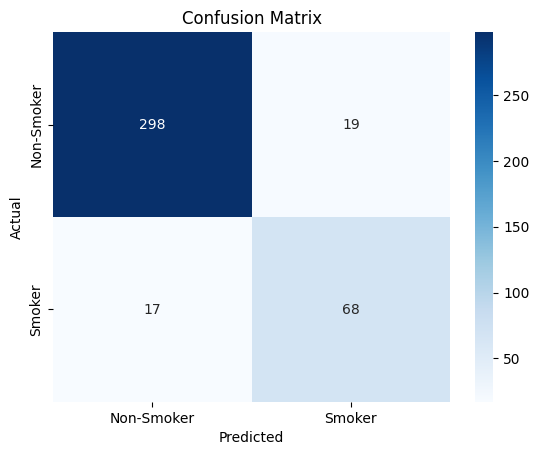

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Smoker', 'Smoker'], yticklabels=['Non-Smoker', 'Smoker'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

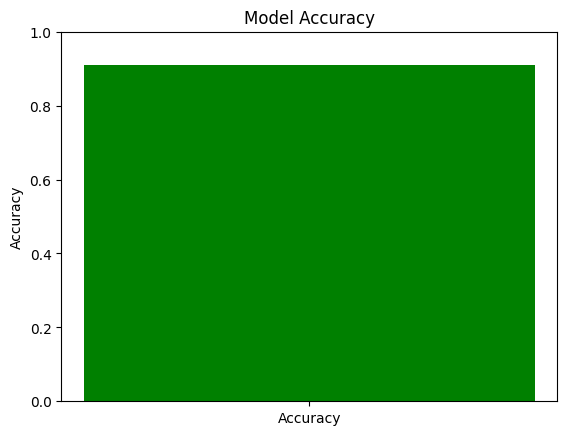

In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, pred)

# Plot the accuracy
plt.bar(['Accuracy'], [accuracy], color='green')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()


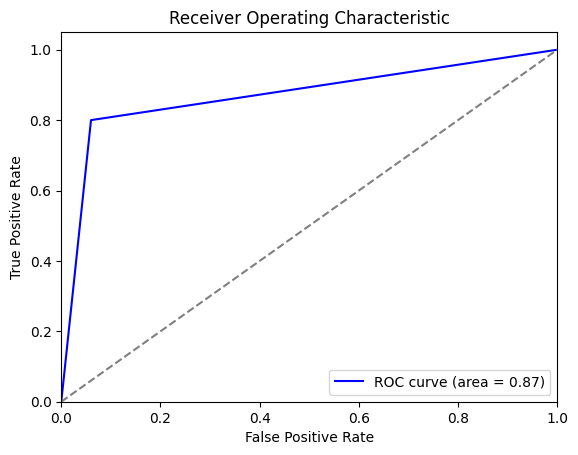

In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, pred)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


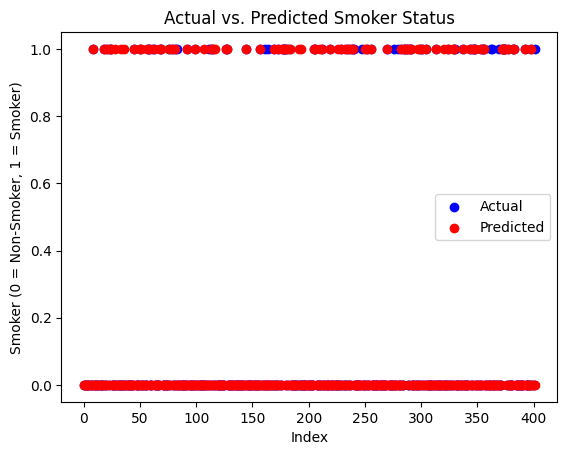

In [ ]:
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_test)), pred, color='red', label='Predicted')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Smoker (0 = Non-Smoker, 1 = Smoker)')
plt.title('Actual vs. Predicted Smoker Status')
plt.show()


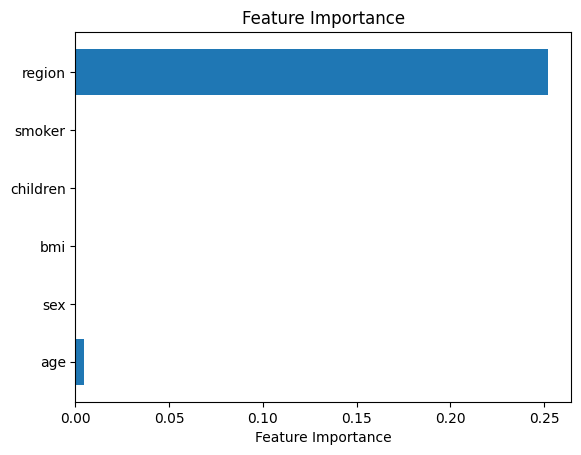

In [ ]:
from sklearn.inspection import permutation_importance

# Get permutation importance of features
result = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)

# Plot the feature importances
feature_importance = result.importances_mean
plt.barh(df.columns[:-1], feature_importance)  # Assuming the last column is 'smoker'
plt.xlabel('Feature Importance')
plt.title('Feature Importance')
plt.show()


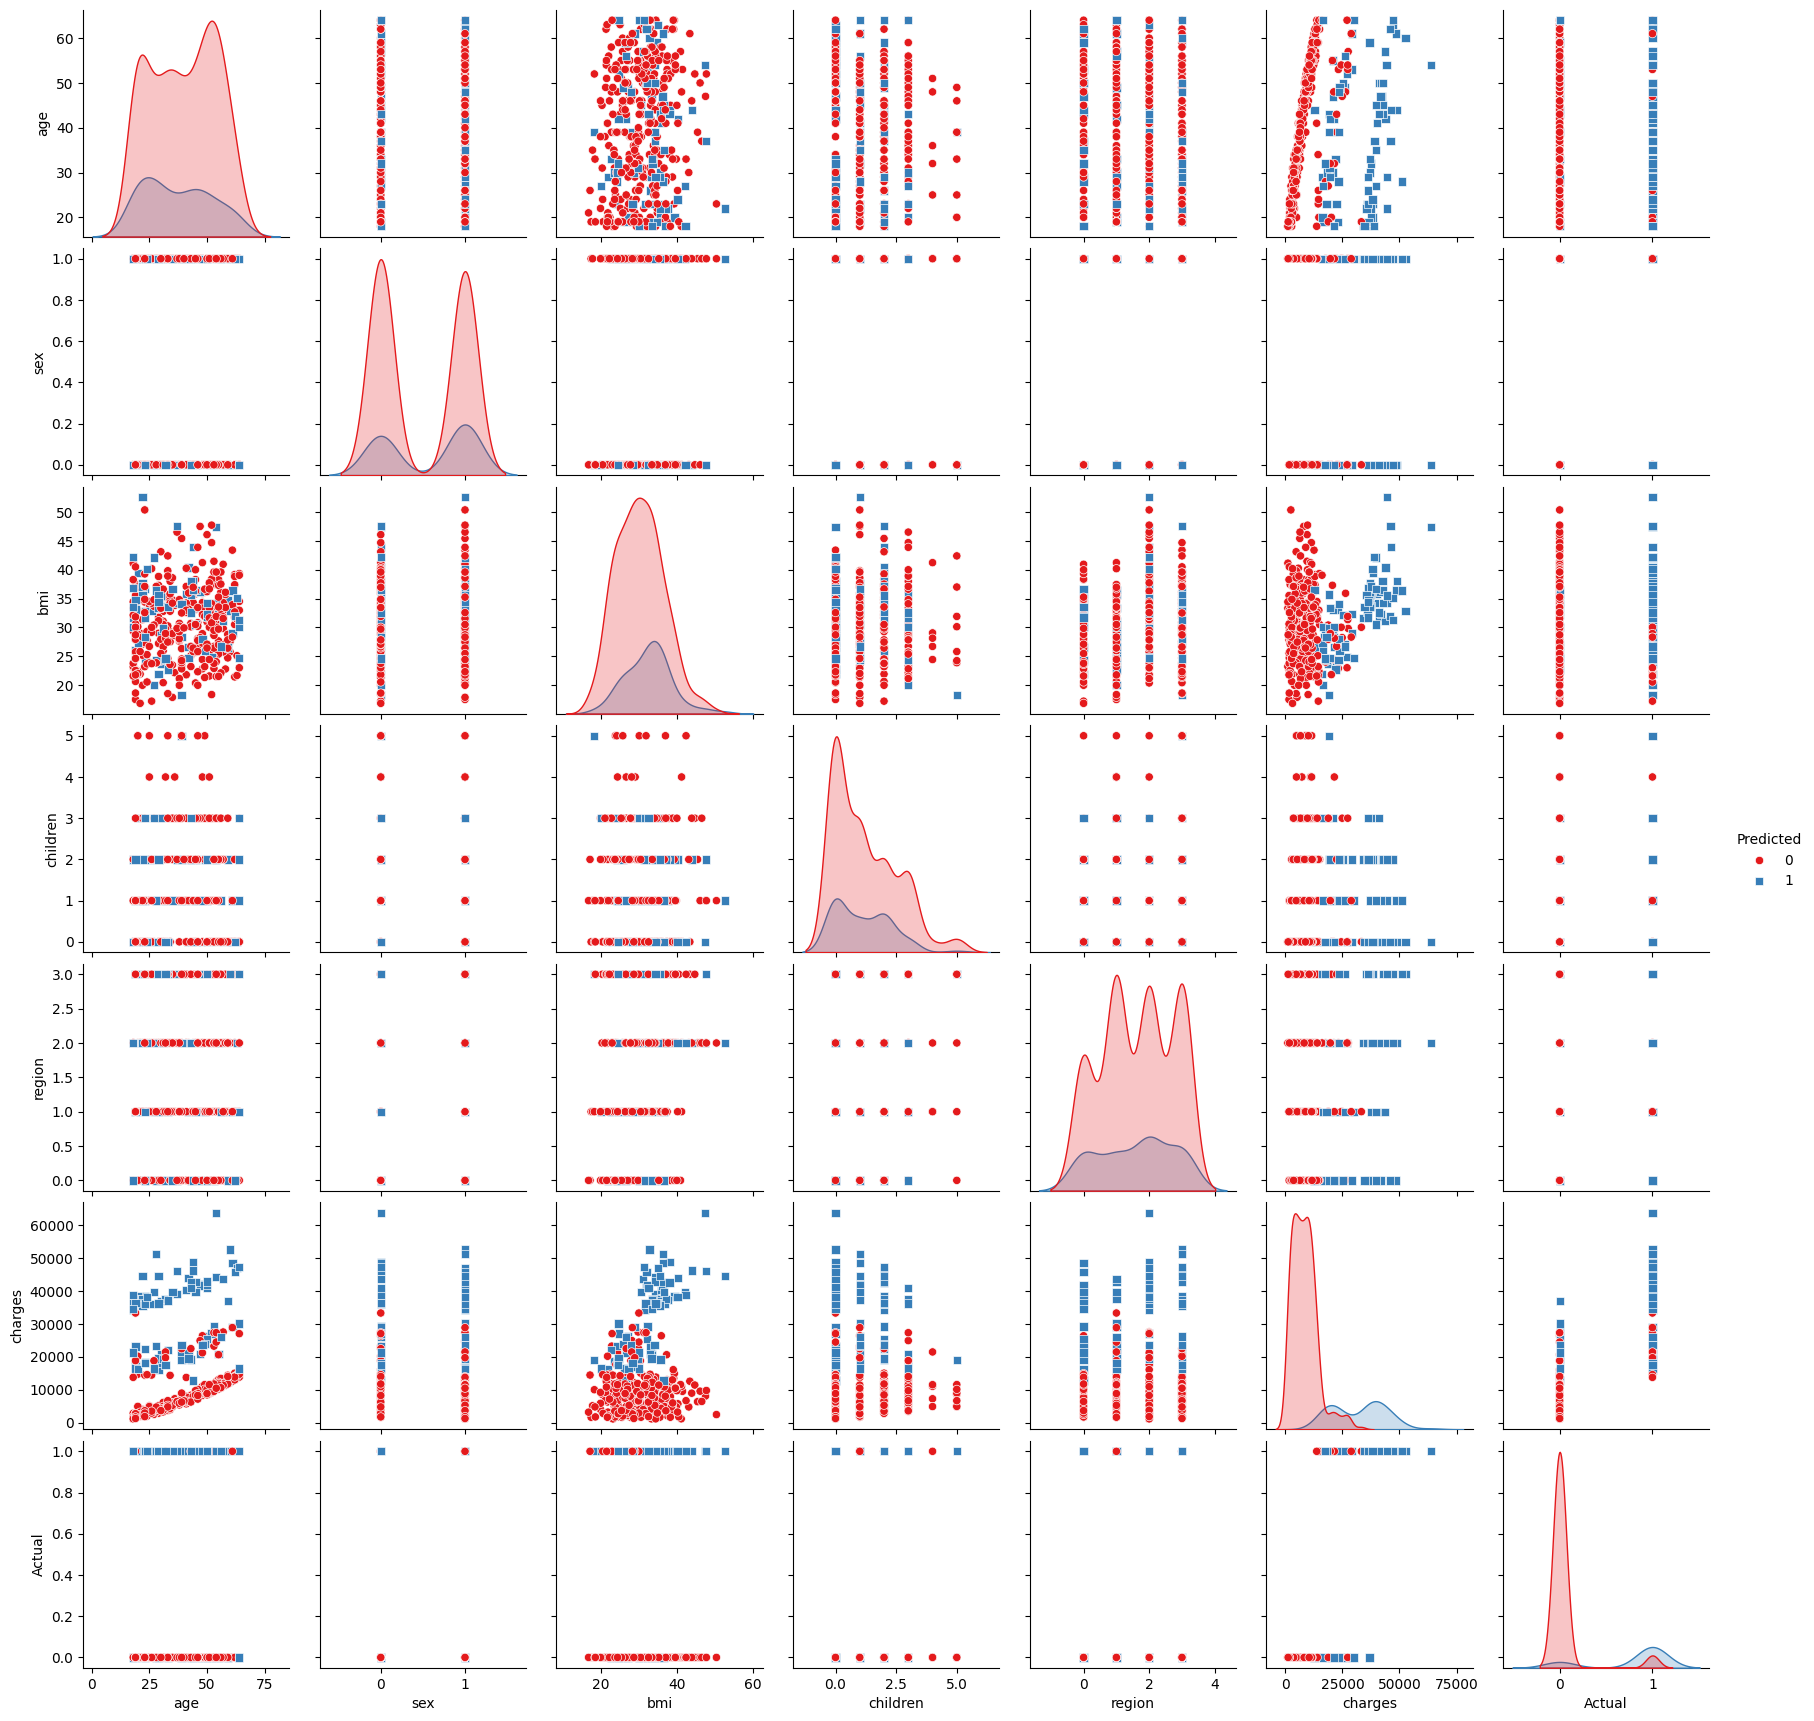

In [ ]:
import seaborn as sns

# Add predictions to the original dataframe
df_test = X_test.copy()
df_test['Actual'] = y_test
df_test['Predicted'] = pred

# Plot the pairplot with color-coded actual or predicted labels
sns.pairplot(df_test, hue='Predicted', markers=["o", "s"], palette="Set1")
plt.show()
